In [1]:
import numpy as np
# from monai.data import DataLoader, CacheDataset
from dataset import get_dataset
from transforms import get_transforms
from monai.transforms import *
import matplotlib.pyplot as plt
import nibabel as nib

In [2]:
all_data = get_dataset("../../data")
all_data

[{'nacpet': '../../data/sub-000/features/nacpet.nii.gz',
  'topogram': '../../data/sub-000/features/topogram.nii.gz',
  'mri_combined_in_phase': '../../data/sub-000/features/mri_combined_in_phase.nii.gz',
  'mri_combined_out_phase': '../../data/sub-000/features/mri_combined_out_phase.nii.gz',
  'mri_face_mask': '../../data/sub-000/features/mri_face_mask.nii.gz',
  'mri_chunk_0_in_phase': '../../data/sub-000/features/mri_chunk_0_in_phase.nii.gz',
  'mri_chunk_0_out_phase': '../../data/sub-000/features/mri_chunk_0_out_phase.nii.gz',
  'mri_chunk_1_in_phase': '../../data/sub-000/features/mri_chunk_1_in_phase.nii.gz',
  'mri_chunk_1_out_phase': '../../data/sub-000/features/mri_chunk_1_out_phase.nii.gz',
  'mri_chunk_2_in_phase': '../../data/sub-000/features/mri_chunk_2_in_phase.nii.gz',
  'mri_chunk_2_out_phase': '../../data/sub-000/features/mri_chunk_2_out_phase.nii.gz',
  'mri_chunk_3_in_phase': '../../data/sub-000/features/mri_chunk_3_in_phase.nii.gz',
  'mri_chunk_3_out_phase': '../../

In [3]:
subject = all_data[0]
subject

{'nacpet': '../../data/sub-000/features/nacpet.nii.gz',
 'topogram': '../../data/sub-000/features/topogram.nii.gz',
 'mri_combined_in_phase': '../../data/sub-000/features/mri_combined_in_phase.nii.gz',
 'mri_combined_out_phase': '../../data/sub-000/features/mri_combined_out_phase.nii.gz',
 'mri_face_mask': '../../data/sub-000/features/mri_face_mask.nii.gz',
 'mri_chunk_0_in_phase': '../../data/sub-000/features/mri_chunk_0_in_phase.nii.gz',
 'mri_chunk_0_out_phase': '../../data/sub-000/features/mri_chunk_0_out_phase.nii.gz',
 'mri_chunk_1_in_phase': '../../data/sub-000/features/mri_chunk_1_in_phase.nii.gz',
 'mri_chunk_1_out_phase': '../../data/sub-000/features/mri_chunk_1_out_phase.nii.gz',
 'mri_chunk_2_in_phase': '../../data/sub-000/features/mri_chunk_2_in_phase.nii.gz',
 'mri_chunk_2_out_phase': '../../data/sub-000/features/mri_chunk_2_out_phase.nii.gz',
 'mri_chunk_3_in_phase': '../../data/sub-000/features/mri_chunk_3_in_phase.nii.gz',
 'mri_chunk_3_out_phase': '../../data/sub-000/

In [4]:
# patch_size= [192,192,192]
# patch_size =[220, 220, 131]
# patch_size = [214, 238, 156]
patch_size = [154, 238, 156]
transforms = get_transforms(patch_size,2)
patch = transforms(subject)

In [5]:
patch = patch[0]
# # list(patch.keys())
patch["ct"].shape

torch.Size([1, 154, 238, 156])

In [6]:
full_ct = nib.load(subject["ct"]).get_fdata()
full_mid = full_ct.shape[-1] // 2
full_mid

265

In [7]:
mid = patch["ct"].shape[-1] // 2
# patch["input"].shape, patch["ct"].shape
mid

78

In [8]:
# images = [patch["input"][0, :,:, 90]]
# images[0].shape

In [9]:
# roi_start = [174,163]
# roi_end = []

In [10]:
# crop_extent = (
#     roi_start[0], roi_start[0] + patch["ct"].shape[1],
#     roi_start[1], roi_start[1] + patch["ct"].shape[2],
# )
crop_extent = (
    174, 328,
    163, 401
)

In [11]:
patch["ct"].shape
# patch["input"].shape

torch.Size([1, 154, 238, 156])

In [32]:
patch.keys()

dict_keys(['topogram', 'mri_face_mask', 'mri_chunk_0_in_phase', 'mri_chunk_0_out_phase', 'mri_chunk_1_in_phase', 'mri_chunk_1_out_phase', 'mri_chunk_2_in_phase', 'mri_chunk_2_out_phase', 'mri_chunk_3_in_phase', 'mri_chunk_3_out_phase', 'sex', 'age', 'height', 'weight', 'ct', 'body_seg', 'organ_seg', 'prediction_mask', 'input'])

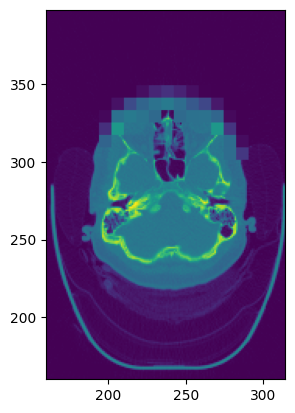

In [36]:
plt.imshow(patch['ct'][0,:,:,80].T, origin="lower", extent=crop_extent)

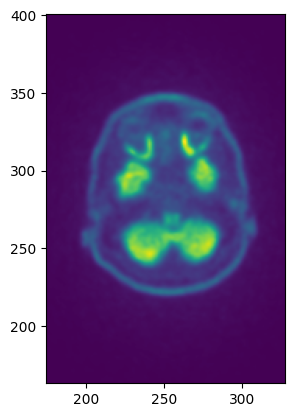

In [13]:
plt.imshow(patch['input'][0,:,:,80].T, origin="lower", extent=crop_extent)

mid is 78


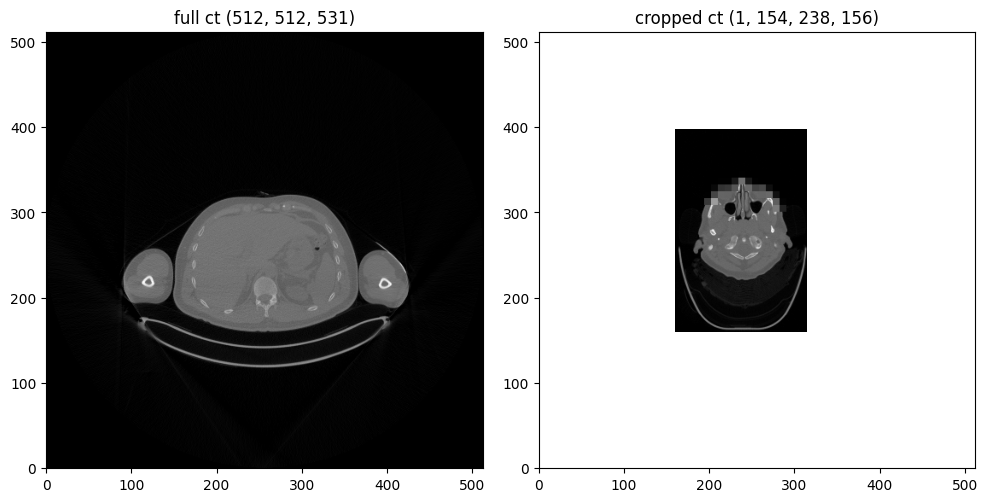

In [14]:
full_ct = nib.load(subject["ct"]).get_fdata()
full_mid = full_ct.shape[-1] // 2
mid = patch["ct"].shape[-1] // 2
print(f"mid is {mid}")

# must match SpatialCropd's roi_start in transforms.py, so the crop is drawn in its real position
roi_start = [160, 160]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(full_ct[..., full_mid].T, cmap="gray", origin="lower", extent=(0, full_ct.shape[0], 0, full_ct.shape[1]))
axes[0].set_title(f"full ct {full_ct.shape}")

crop_extent = (
    roi_start[0], roi_start[0] + patch["ct"].shape[1],
    roi_start[1], roi_start[1] + patch["ct"].shape[2],
)
axes[1].imshow(patch["ct"][0, ..., 70].T, cmap="gray", origin="lower", extent=crop_extent)
axes[1].set_title(f"cropped ct {tuple(patch['ct'].shape)}")

# same physical extent on both axes so the crop's true size and position are visible
for ax in axes:
    ax.set_xlim(0, full_ct.shape[0])
    ax.set_ylim(0, full_ct.shape[1])
plt.tight_layout()

In [15]:
filepath= "../../data/sub-000/ct-label/organ_seg.nii.gz"
img = nib.load(filepath)
data = img.get_fdata()
data.shape

(512, 512, 531)

In [16]:
brain = data==90
xs, ys, zs = np.where(brain)

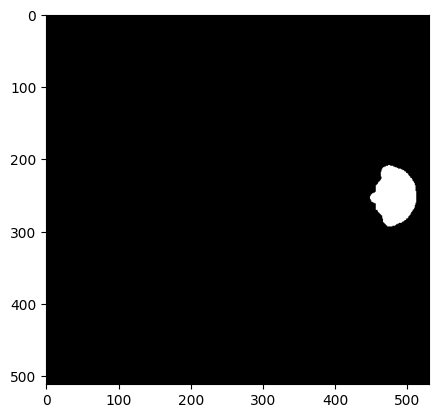

In [17]:
plt.imshow(data[:,270,:]==90, cmap="gray")

In [18]:
a = [(np.int64(212), np.int64(296)), (np.int64(239), np.int64(347)), (np.int64(421), np.int64(488))]

# Compute mean of each tuple position
bbox = []
for item in a:
    bbox.append(tuple(sum(col) / len(col) for col in zip(*a)))


In [19]:
tuple1 = ((np.int64(209), np.int64(293)), (np.int64(228), np.int64(339)), (np.int64(447), np.int64(512)))

In [20]:
tuple2 = ((np.int64(206), np.int64(293)), (np.int64(227), np.int64(339)), (np.int64(417), np.int64(490)))

In [21]:
len(tuple1)

3

In [22]:
tuple_list= []
for i in range(len(tuple1)):
    tuple_list.append(np.add(tuple1[i],tuple2[i]))

In [23]:
tuple_list

[array([415, 586]), array([455, 678]), array([ 864, 1002])]